# Behavioural analyses – Figure 1

Hierarchical linear models of confidence for the four experiments, fitted separately in each goal frame with R `lme4` (through the Python package `pymer4`):

`zConf ~ zabsDValue + zRT + zChoValue + zUnchoValue + (zabsDValue + zRT + zChoValue + zUnchoValue | Part)`

All variables are z-scored within participant. For each experiment the notebook prints the fixed effects for both frames and plots:
1. fixed effects (bars, 95% CI) and participant-level coefficients (dots) for all predictors;
2. the chosen and unchosen evidence coefficients only (Figure 1B, D, F, H, left);
3. β<sub>chosen</sub> + β<sub>unchosen</sub> per participant, tested against 0 and between frames (Figure 1B, D, F, H, right).

It also tests |β<sub>chosen</sub>| vs |β<sub>unchosen</sub>| within each frame.

**Requirements:** R with `lme4` and `lmerTest`, plus `pymer4` (0.9 API) and `polars` in Python. Helper functions are imported from `../AnalysisModel/functionsSims.py`.

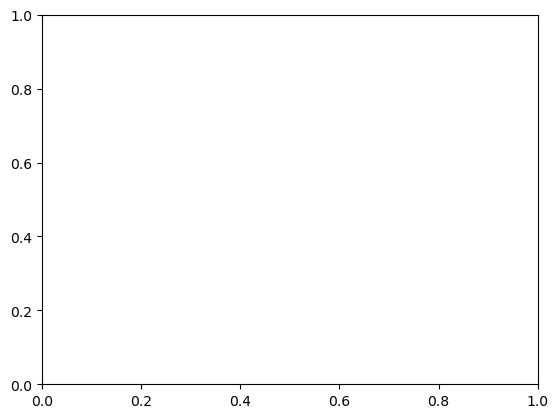

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import seaborn as sns

from pathlib import Path
import sys

# Shared helper functions live in ../AnalysisModel
package_root = Path.cwd().parent / "AnalysisModel"
sys.path.insert(0, str(package_root))

import functionsSims as fs

In [2]:
# Mixed-effects models (R lme4) from Python
from pymer4.models import lmer

In [4]:
# Add z-scored predictors (within participant): left/right evidence, confidence, RT,
# chosen/unchosen evidence and |ΔEvidence| (right - left)
def mainLoad(data_part_all0):

    # z-score values
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

    data_part_all0['DValue'] = data_part_all0['RValue'] - data_part_all0['LValue']
    data_part_all0['absDValue'] = np.abs(data_part_all0['DValue'])

    data_part_all0['choValue'] = data_part_all0.apply(lambda row: row.RValue if row.ChosenITM==1 else row.LValue, axis=1)
    data_part_all0['unchoValue'] = data_part_all0.apply(lambda row: row.LValue if row.ChosenITM==1 else row.RValue, axis=1)

    data_part_all0['zChoValue'] = fs.zscore1(data_part_all0,'choValue', 'Part')
    data_part_all0['zUnchoValue'] = fs.zscore1(data_part_all0,'unchoValue', 'Part')

    data_part_all0['zDValue'] = fs.zscore1(data_part_all0,'DValue', 'Part')
    data_part_all0['zabsDValue'] = fs.zscore1(data_part_all0,'absDValue', 'Part')

    return data_part_all0   

In [9]:
import matplotlib.patches as mpatches

# Bar plot of fixed effects (95% CI) for two frames side by side, with participant-level coefficients as dots
def Coefpresplot_bar2(regtable1, mixtable1,regtable2, mixtable2, intercept=True, barcol1='#000000',barcol2='#000000', title='Regression Coefficients', size='big', ylimits=(), ymultiple=0.5, ticklabsize=25, n_ET_predictors = 0, hatch2 ='',labels = ['',''] ):

    # Import locators so that we can tidy up the yaxis
    from matplotlib.ticker import MultipleLocator

    # rounding function to get edges to even 0.5 values
    def round_to(n, precision):
        correction = 0.5 if n >= 0 else -0.5
        return int( n/precision+correction ) * precision

    def round_to_5(n):
        return round_to(n, 0.5)

    # Set seaborn style for the plot
    sns.set(style='white')

    bar_sep= 0.25

    # Generate the figure
    if size=='big':
        fig = plt.figure(figsize=[15,8])
    elif size=='long':
        fig = plt.figure(figsize=[15,4])
    elif size=='narrow':
        fig = plt.figure(figsize=[10,4])

    fig.suptitle(title, fontsize=24)
    ax = fig.add_subplot()

    # Set axis limits based on whether to include the intercept or not   
    # Assumuing that regtable1 and regtable2 have exactly the same number of coefficients
    XLim = (0, len(regtable1.columns)+1  )
    YLim = (round_to_5(np.min([np.min(mixtable1),np.min(mixtable2)]))-0.2, round_to_5(np.max([np.max(mixtable1),np.max(mixtable2)]))+0.2)
    ax.set_xlim(XLim)
    ax.set_ylim(YLim)

    # Draw a line through the 0-value on the y-axis
    line = ax.plot(XLim, [0, 0], color='black', ls='--', alpha = 0.5, lw=3)

    # If intercept is true, plot the coefficient for the intercept
    # Assumuing that regtable1 and regtable2 have exactly the same number of coefficients

    Coefficients = regtable1.columns

    # Determine the colours for the coefficients based on the n_ET_variable
    n_predictors = len(Coefficients)
    n_non_ET_predictors = n_predictors - n_ET_predictors

    # Color for conditions 1 and 2
    colourlist1 = [barcol1] * n_non_ET_predictors + ['#03719c'] * n_ET_predictors
    colourlist2 = [barcol2] * n_non_ET_predictors + ['#03719c'] * n_ET_predictors

    # Plot all the coefficients with 95% CI
    position = 0
    for Coefficient in Coefficients:
        # Plot condition 1
        position += 1
        ax.bar(position-bar_sep, regtable1.loc['Estimate', Coefficient], width=0.4,color=colourlist1[position-1],)
        ax.errorbar(position-bar_sep, regtable1.loc['Estimate', Coefficient],
                    yerr=regtable1.loc['SE', Coefficient]*1.96, lw=2, color='#000000')

        # Plot condition 2
        ax.bar(position+bar_sep, regtable2.loc['Estimate', Coefficient], width=0.4,color=colourlist2[position-1],)
        ax.errorbar(position+bar_sep, regtable2.loc['Estimate', Coefficient],
                    yerr=regtable2.loc['SE', Coefficient]*1.96, lw=2, color='#000000')

# Plot dots for the individual coefficients
    # Assumuing that mixtable1 and mixtable2 have exactly the same number of elements 

    coef_num1 = range(0,len(mixtable1)) 
    for i in coef_num1:
        # Plot dots condition 1
        part_coefs = mixtable1.iloc[i]
        position_parts= range(len(part_coefs))
        jittr = np.random.uniform(low=-0.2,high=0.2,size=len(part_coefs))/2
        ax.plot(np.sum([list(position_parts) ,1 -  bar_sep+jittr], axis = 0), part_coefs.values, marker='o', ms=8, color='#000000',alpha=0.3,linestyle="None")

    coef_num2 = range(0,len(mixtable2)) 

    for i in coef_num2:       

        # Plot dots condition 1
        part_coefs = mixtable2.iloc[i]
        position_parts= range(len(part_coefs))
        jittr = np.random.uniform(low=-0.2,high=0.2,size=len(part_coefs))/2
        ax.plot(np.sum([list(position_parts) , 1 +bar_sep-jittr], axis = 0), part_coefs.values, marker='o', ms=8, color='#000000',alpha=0.3,linestyle="None")

    # Setting the x-axis major tick's location
    ax.set_xticks(range(1, len(regtable1.columns)+1))

    # set the y-axis major tick position
    ax.yaxis.set_major_locator(MultipleLocator(ymultiple))

    # Setting the x-axis major tick's label

    ax.set_xticklabels(regtable1.columns, rotation=0)        

    ax.tick_params(axis='both', which='major', labelsize=ticklabsize)
    ax.set_ylabel('Regression Coefficients', fontsize=25)
    ax.xaxis.set_tick_params(labelsize=25)

    # Autoformats the ticklabels for the xaxis
    fig.autofmt_xdate()

    patch1 = mpatches.Patch(facecolor=colourlist1[position-1],hatch=r'', label=labels[0])
    patch2 = mpatches.Patch(facecolor=colourlist2[position-1],hatch=r'', label=labels[1])

    leg = plt.legend(handles=[patch1,patch2],fontsize=25)
    leg.get_frame().set_facecolor('none')
    leg.get_frame().set_linewidth(0.0)

    sns.despine()

    return fig, ax

In [10]:
import matplotlib.patches as mpatches

# Same as Coefpresplot_bar2, restricted to the last two predictors (chosen and unchosen evidence)
def Coefpresplot_bar2_onlyLastTwo(regtable1, mixtable1,regtable2, mixtable2, intercept=True, barcol1='#000000',barcol2='#000000', title='Regression Coefficients', size='big', ylimits=(), ymultiple=0.5, ticklabsize=25, n_ET_predictors = 0, hatch2 ='',labels = ['',''] ):

        # Import locators so that we can tidy up the yaxis
        from matplotlib.ticker import MultipleLocator

        # Keep only the last two predictors (chosen and unchosen evidence)
        regtable1 = regtable1.iloc[:, -2:]
        regtable2 = regtable2.iloc[:, -2:]
        mixtable1 = mixtable1.iloc[:, -2:]
        mixtable2 = mixtable2.iloc[:, -2:]

        # rounding function to get edges to even 0.5 values
        def round_to(n, precision):
            correction = 0.5 if n >= 0 else -0.5
            return int( n/precision+correction ) * precision

        def round_to_5(n):
            return round_to(n, 0.5)
                
        # Set seaborn style for the plot
        sns.set(style='white')
        
        bar_sep= 0.25
        
        # Generate the figure
        if size=='big':
            fig = plt.figure(figsize=[15,8])
        elif size=='long':
            fig = plt.figure(figsize=[15,4])
        elif size=='narrow':
            fig = plt.figure(figsize=[8,8])
                
        fig.suptitle(title, fontsize=24)
        ax = fig.add_subplot()
        
        # axis limits
        YLim = (round_to_5(np.min([np.min(mixtable1), np.min(mixtable2)])) - 0.2,
                round_to_5(np.max([np.max(mixtable1), np.max(mixtable2)])) + 0.2)
        ax.set_ylim(YLim)
        
        ax.axhline(0, color='black', ls='--', alpha=0.5, lw=3)
        
        # coefficients and colors
        Coefficients = regtable1.columns
        n_predictors = len(Coefficients)
        n_non_ET_predictors = n_predictors - n_ET_predictors
        
        colourlist1 = [barcol1] * n_non_ET_predictors + ['#03719c'] * n_ET_predictors
        colourlist2 = [barcol2] * n_non_ET_predictors + ['#03719c'] * n_ET_predictors
        
        # positions: group1 then group2
        positions1 = np.arange(1, n_predictors+1)                     # regtable1 group
        positions2 = np.arange(n_predictors+2, 2*n_predictors+2)      # regtable2 group
        
        # ---- Bars for regtable1 ----
        for i, coef in enumerate(Coefficients):
            pos = positions1[i]
            ax.bar(pos, regtable1.loc['Estimate', coef], width=0.6,
                color=colourlist1[i])
            ax.errorbar(pos, regtable1.loc['Estimate', coef],
                        yerr=regtable1.loc['SE', coef]*1.96,
                        lw=2, color='black')

        # ---- Bars for regtable2 ----
        for i, coef in enumerate(Coefficients):
            pos = positions2[i]
            ax.bar(pos, regtable2.loc['Estimate', coef], width=0.6,
                color=colourlist2[i])
            ax.errorbar(pos, regtable2.loc['Estimate', coef],
                        yerr=regtable2.loc['SE', coef]*1.96,
                        lw=2, color='black')

        # ---- Mixtable dots (regtable1) ----
        for i in range(len(mixtable1)):
            part_coefs = mixtable1.iloc[i]
            jittr = np.random.uniform(low=-0.2, high=0.2, size=n_predictors)
            ax.plot(positions1 + jittr, part_coefs.values,
                    'o', ms=8, color='black', alpha=0.3)

        # ---- Mixtable dots (regtable2) ----
        for i in range(len(mixtable2)):
            part_coefs = mixtable2.iloc[i]
            jittr = np.random.uniform(low=-0.2, high=0.2, size=n_predictors)
            ax.plot(positions2 + jittr, part_coefs.values,
                    'o', ms=8, color='black', alpha=0.3)

        # ---- X-axis ticks/labels ----
        xticks = np.concatenate([positions1, positions2])
        xticklabels = list(Coefficients) + list(Coefficients)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=45, ha="right")

        # y-axis ticks
        ax.yaxis.set_major_locator(MultipleLocator(ymultiple))

        ax.tick_params(axis='both', which='major', labelsize=ticklabsize)
        ax.set_ylabel('Regression Coefficients', fontsize=25)
        
        fig.autofmt_xdate()
        
        # legend patches
        patch1 = mpatches.Patch(facecolor=colourlist1[0], label=labels[0])
        patch2 = mpatches.Patch(facecolor=colourlist2[0], label=labels[1])
        leg = plt.legend(handles=[patch1, patch2], fontsize=25)
        leg.get_frame().set_facecolor('none')
        leg.get_frame().set_linewidth(0.0)
        
        sns.despine()
        return fig, ax

In [11]:
import polars as pl

# Fit the confidence model in each frame (positive = high-evidence goal, negative = low-evidence goal),
# print the results, plot the coefficients and test the chosen/unchosen evidence effects
def regressionHuman_ChoUncho(data_part_all_Pos,data_part_all_Neg, labels = ['|ΔValue|','RT','ChoValue', 'UnchoValue'], labelFrame = ['Like','Dislike'], formula =  "zConf ~ zRT +  zChoValue + zUnchoValue + ( zRT +  zChoValue + zUnchoValue|Part) "):

    regFormula1 = formula

    model1 = lmer(regFormula1, data=pl.from_pandas(data_part_all_Pos))
    model2 = lmer(regFormula1, data=pl.from_pandas(data_part_all_Neg))
    model1.fit(); model2.fit()

    def old_format(model):
        rf = model.result_fit.to_pandas().set_index('term')
        coefs = rf.rename(columns={'estimate': 'Estimate', 'conf_low': '2.5_ci', 'conf_high': '97.5_ci',
                                'std_error': 'SE', 'df': 'DF', 'statistic': 'T-stat', 'p_value': 'P-val'})
        fixef = model.fixef.to_pandas().set_index('level')
        return coefs, fixef

    coefs1, par_table_data1 = old_format(model1)
    coefs2, par_table_data2 = old_format(model2)
    table_data1 = coefs1.T
    table_data2 = coefs2.T

    print("Regression results for Positive Frame:")
    print(table_data1)
    print("\nRegression results for Negative Frame:")
    print(table_data2)

    fig1,ax1 = Coefpresplot_bar2(table_data1, par_table_data1,table_data2, par_table_data2, barcol1='#4F6A9A',barcol2='#AC5255', 
                    title='', size='big',ymultiple=0.3, ticklabsize=20,labels=labelFrame,intercept = False)

    plt.xticks([x+1 for x in range(len(table_data1.columns)) ] ,  labels, rotation=0,horizontalalignment='center')

    plt.xlim(1.5, len(table_data1.columns)+0.5)

    [s, p] = stats.ttest_rel(np.absolute(par_table_data1['zChoValue']),np.absolute(par_table_data1['zUnchoValue']))
    print(str('Pos / Magnitude compare / Chosen effect = '+ str(round(np.mean(np.absolute(par_table_data1['zChoValue'])),2))+ ";Unchosen effect  = "+ str(round(np.mean(np.absolute(par_table_data1['zUnchoValue'])),2))+
        "; t =  " + str(round(s,3)) + " ; p-value =" + str(p)))

    [s, p] = stats.ttest_rel(np.absolute(par_table_data2['zChoValue']),np.absolute(par_table_data2['zUnchoValue']))
    print(str('Neg / Magnitude compare / Chosen effect = '+ str(round(np.mean(np.absolute(par_table_data2['zChoValue'])),2))+ ";Unchosen effect  = "+ str(round(np.mean(np.absolute(par_table_data2['zUnchoValue'])),2))+
        "; t =  " + str(round(s,3)) + " ; p-value =" + str(p)))

    fig3,ax3 = Coefpresplot_bar2_onlyLastTwo(table_data1, par_table_data1,table_data2, par_table_data2, barcol1='#4F6A9A',barcol2='#AC5255', 
                    title='', size='narrow',ymultiple=0.3, ticklabsize=20,labels=labelFrame,intercept = False)

    plt.xticks([x+1 for x in range(len(table_data1.columns[-2:])) ] + [x+2+len(table_data1.columns[-2:]) for x in range(len(table_data2.columns[-2:])) ],labels[-2:] + labels[-2:], rotation=0,horizontalalignment='center')

    plt.show()

    # generate plot to compare chosen vs unchosen
    barcol1='#4F6A9A'
    barcol2='#AC5255'
    fig2 = plt.figure(figsize=[2,8])

    ax2 = fig2.add_subplot()

    bChoMinusUncho_1 = par_table_data1['zChoValue'] + par_table_data1['zUnchoValue']
    bChoMinusUncho_2 = par_table_data2['zChoValue'] + par_table_data2['zUnchoValue']

    ax2.bar(1, np.mean(bChoMinusUncho_1), width=0.4,color=barcol1)
    ax2.errorbar(1, np.mean(bChoMinusUncho_1),
                yerr= stats.sem(bChoMinusUncho_1), lw=2, color='#000000')
    
    ax2.bar(2, np.mean(bChoMinusUncho_2), width=0.4,color=barcol2)
    ax2.errorbar(2, np.mean(bChoMinusUncho_2),
                yerr= stats.sem(bChoMinusUncho_2), lw=2, color='#000000')
    
    # add scatter points , include some jitter in the x-axis
    x1 = np.random.normal(1, 0.05, len(bChoMinusUncho_1))
    x2 = np.random.normal(2, 0.05, len(bChoMinusUncho_2))
    ax2.plot(x1, bChoMinusUncho_1, 'o', color='black', alpha=0.5)
    ax2.plot(x2, bChoMinusUncho_2, 'o', color='black', alpha=0.5)

    ax2.set_ylabel('$\\beta_{Chosen}$  + $\\beta_{Unchosen}$  ', fontsize=25)

    ax2.set_xticks([])        

    ax2.tick_params(axis='y', labelsize= 20 )    
    #horizontal line
    ax2.axhline(0, color='black', lw=2, alpha=0.5)
    ax2.set_xlim(0.5,2.5)

    # t-test one sample different from 0
    [s, p] = stats.ttest_1samp(bChoMinusUncho_1, 0)
        # add star is significant
    if p < 0.05:
        start_text = "*"
    elif p < 0.01:
        start_text = "**"
    elif p < 0.001:
        start_text = "***"
    else:
        start_text = ""
    # Determine max height and x position for annotation
    max_height = max(bChoMinusUncho_1) + 0.001  # Maximum bar height
    mid_x = 1  # Middle x position
    # Draw significance marker
    plt.text(mid_x, max_height , start_text, fontsize=35, ha="center")  # Significance star

    # t-test one sample different from 0
    [s, p] = stats.ttest_1samp(bChoMinusUncho_2, 0)
        # add star is significant
    if p < 0.05:
        start_text = "*"
    elif p < 0.01:
        start_text = "**"
    elif p < 0.001:
        start_text = "***"
    else:
        start_text = ""
    # Determine max height and x position for annotation
    mid_x = 2  # Middle x position
    # Draw significance marker
    plt.text(mid_x, max_height , start_text, fontsize=35, ha="center")  # Significance star

    sns.despine()
    plt.show()

    [s, p] = stats.ttest_rel(bChoMinusUncho_1, bChoMinusUncho_2)
    print('t-test positive vs negative frame = ' + str(round(np.mean(bChoMinusUncho_1),2))+ " +- " + str(stats.sem(bChoMinusUncho_1))+ " vs " + str(round(np.mean(bChoMinusUncho_2),2)) + " +-" + str(stats.sem(bChoMinusUncho_2)))
              
    print("; t =  " + str(round(s,3)) + " ; p-value =" + str(p))

    #         try:
    #         except Exception:
    #             pass

## Experiment 1 – value-based choice

================  Pos frame =====================
================  Neg frame =====================
R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] 0.03188755

Regression results for Positive Frame:
term       (Intercept)  zabsDValue           zRT     zChoValue  zUnchoValue
Estimate  1.255634e-17    0.030116 -2.620607e-01  2.188030e-01    -0.077669
SE        1.453828e-02    0.025630  3.319400e-02  2.681573e-02     0.027938
2.5_ci   -2.850410e-02   -0.024231 -3.298543e-01  1.635407e-01    -0.135051
97.5_ci   2.850410e-02    0.084463 -1.942670e-01  2.740652e-01    -0.020288
t_stat    8.636743e-16    1.175034 -7.894820e+00  8.159500e+00    -2.780058
DF        3.596463e+03   15.946783  2.

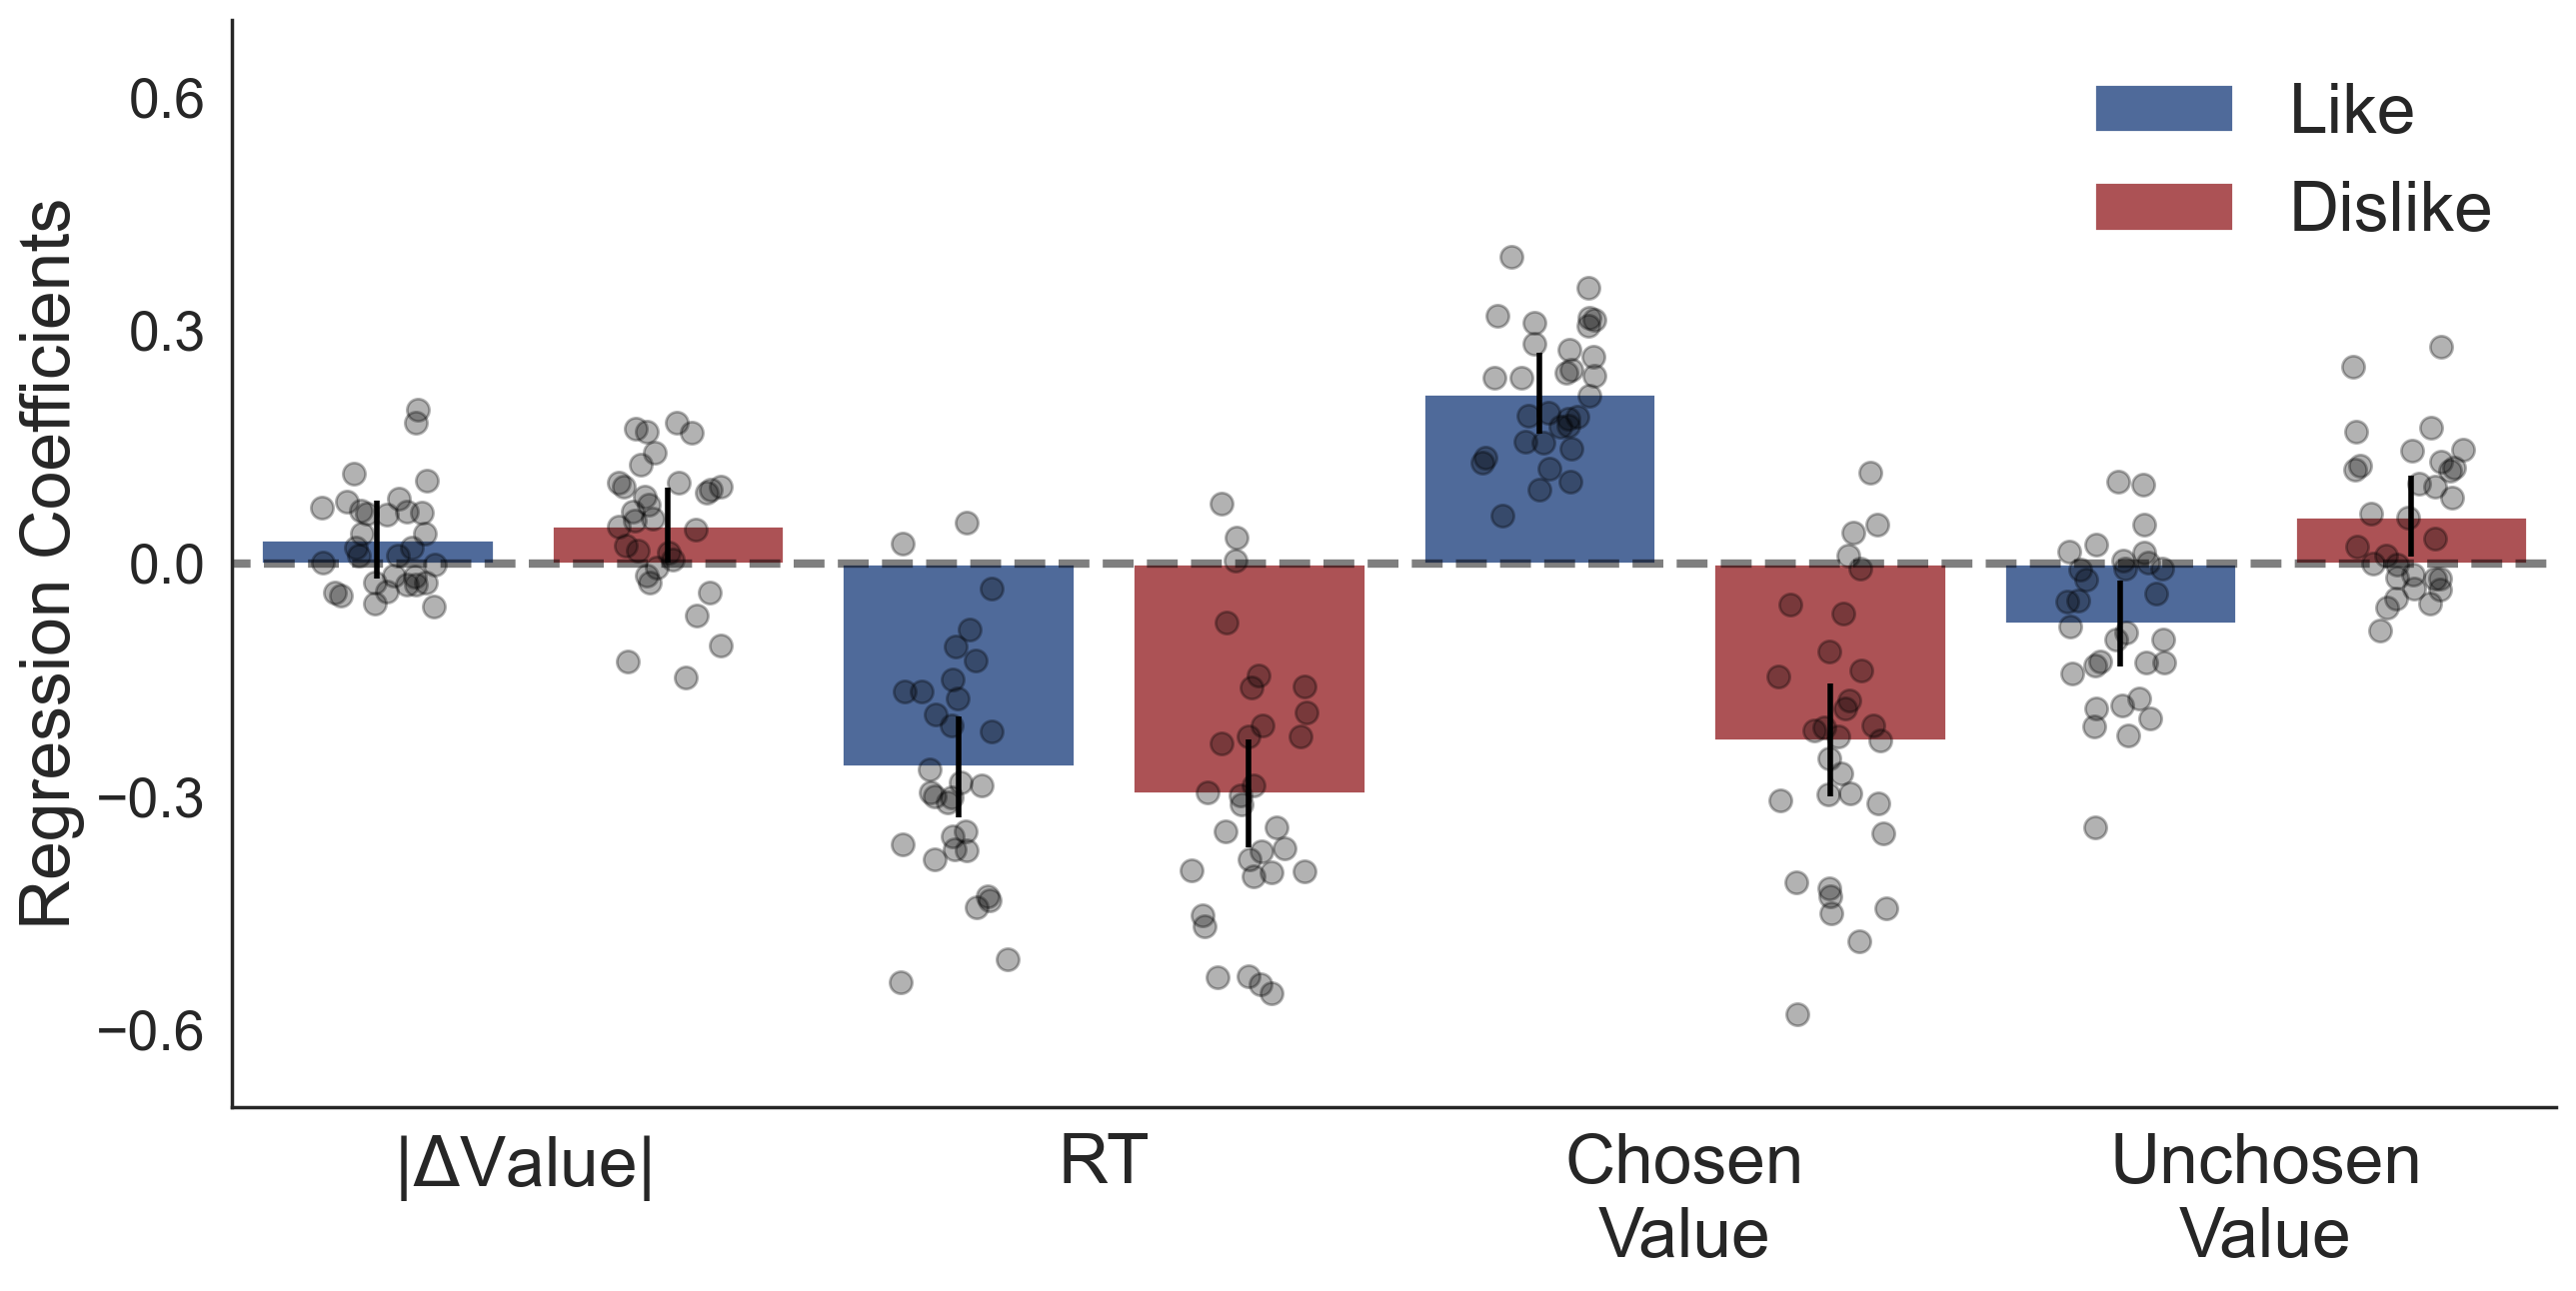

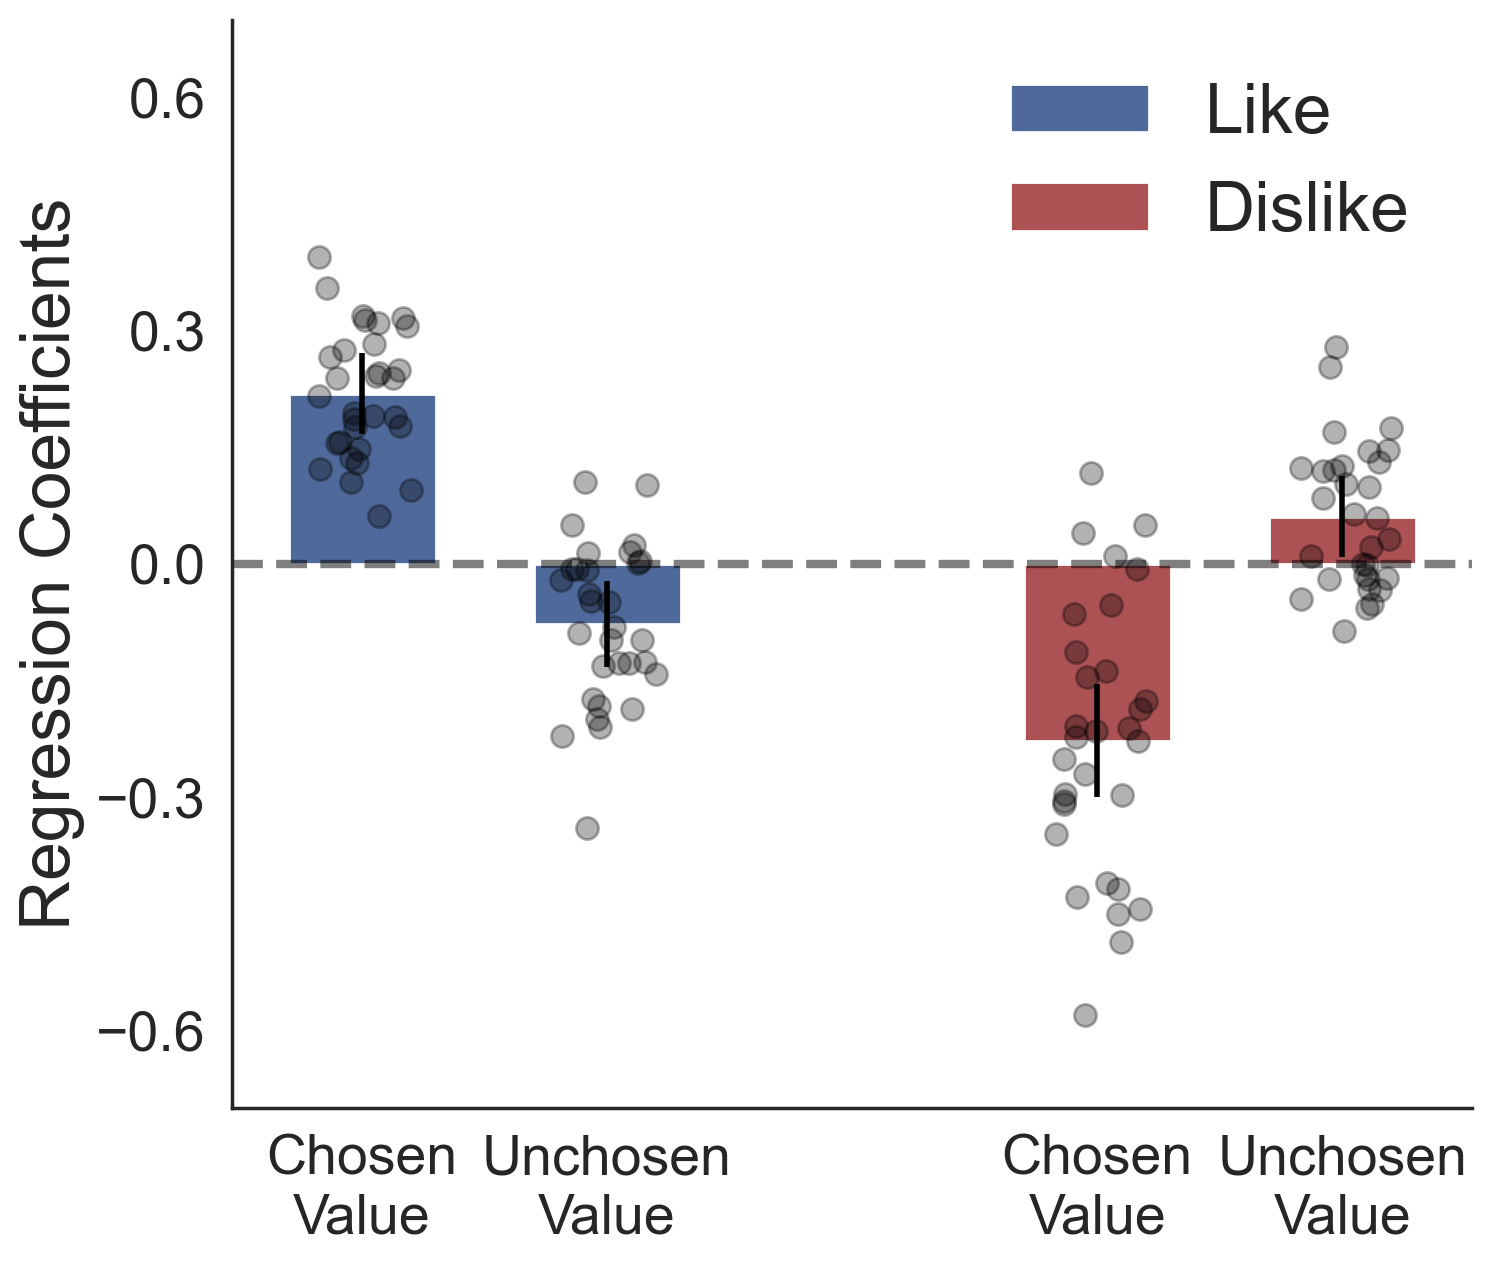

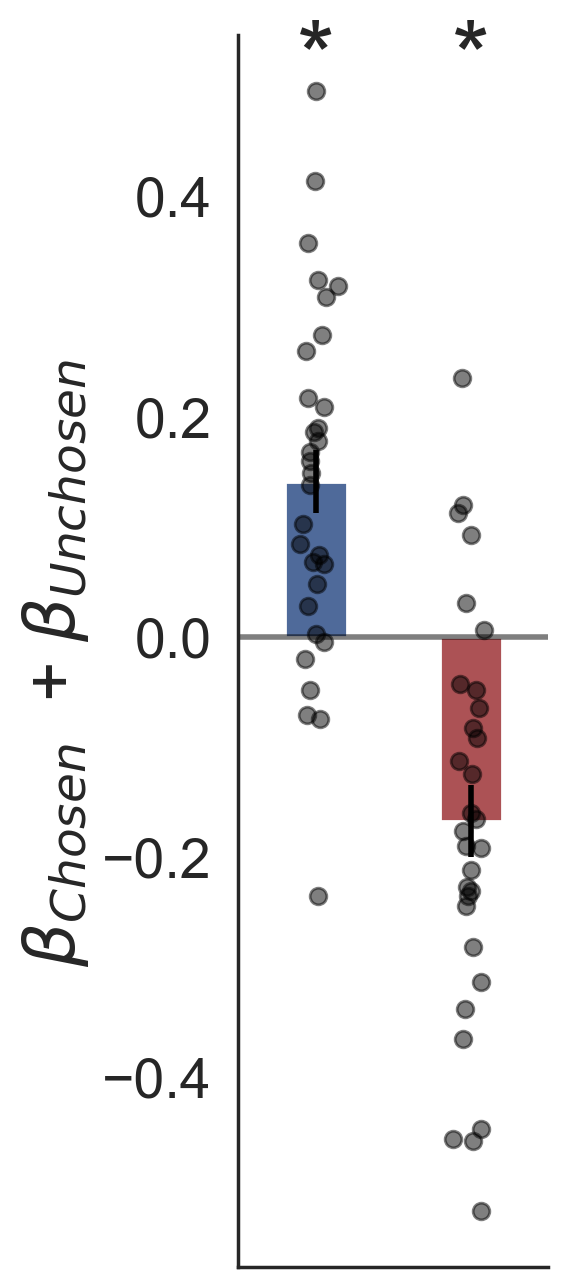

t-test positive vs negative frame = 0.14 +- 0.028716046725923247 vs -0.17 +-0.03300477711815738
; t =  8.957 ; p-value =5.578687583711885e-10


In [13]:
# Figure 1B: frames Like (BlockCond == 1) / Dislike (BlockCond == 2)
data_all = pd.read_csv('../Data/Sepulveda2020/DataFoodFramingNotebook_31.csv') 
# Positive (high-evidence goal) frame

print('================  Pos frame =====================')

data_part_all0 =  data_all.loc[data_all.BlockCond == 1]
data_part_all_Pos     = mainLoad(data_part_all0)

# Negative (low-evidence goal) frame

print('================  Neg frame =====================')
data_part_all0 =  data_all.loc[data_all.BlockCond == 2]
data_part_all_Neg     = mainLoad(data_part_all0)

regressionHuman_ChoUncho(data_part_all_Pos,data_part_all_Neg, labels = ['Inter','|$\Delta$Value|','RT','Chosen\nValue', 'Unchosen\nValue'], labelFrame = ['Like','Dislike'],
                         formula =  "zConf ~ zabsDValue+ zRT +  zChoValue + zUnchoValue + (zabsDValue + zRT +  zChoValue + zUnchoValue|Part) ")

## Experiment 2 – dot numerosity

================  Pos frame =====================
================  Neg frame =====================
R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

Regression results for Positive Frame:
term       (Intercept)  zabsDValue           zRT     zChoValue   zUnchoValue
Estimate -4.135437e-17   -0.013911 -3.269909e-01  5.391129e-01 -4.432105e-01
SE        1.463520e-02    0.026386  2.572330e-02  5.731377e-02  5.169763e-02
2.5_ci   -2.869367e-02   -0.067618 -3.794655e-01  4.265262e-01 -5.447424e-01
97.5_ci   2.869367e-02    0.039796 -2.745162e-01  6.516995e-01 -3.416785e-01
t_stat   -2.825678e-15   -0.527213 -1.271185e+01  9.406341e+00 -8.573129e+00
DF        3.772770e+03   32.616095  3.083146e+01  5.370618e+02  5.951502e+02
P-val     1.000000e+

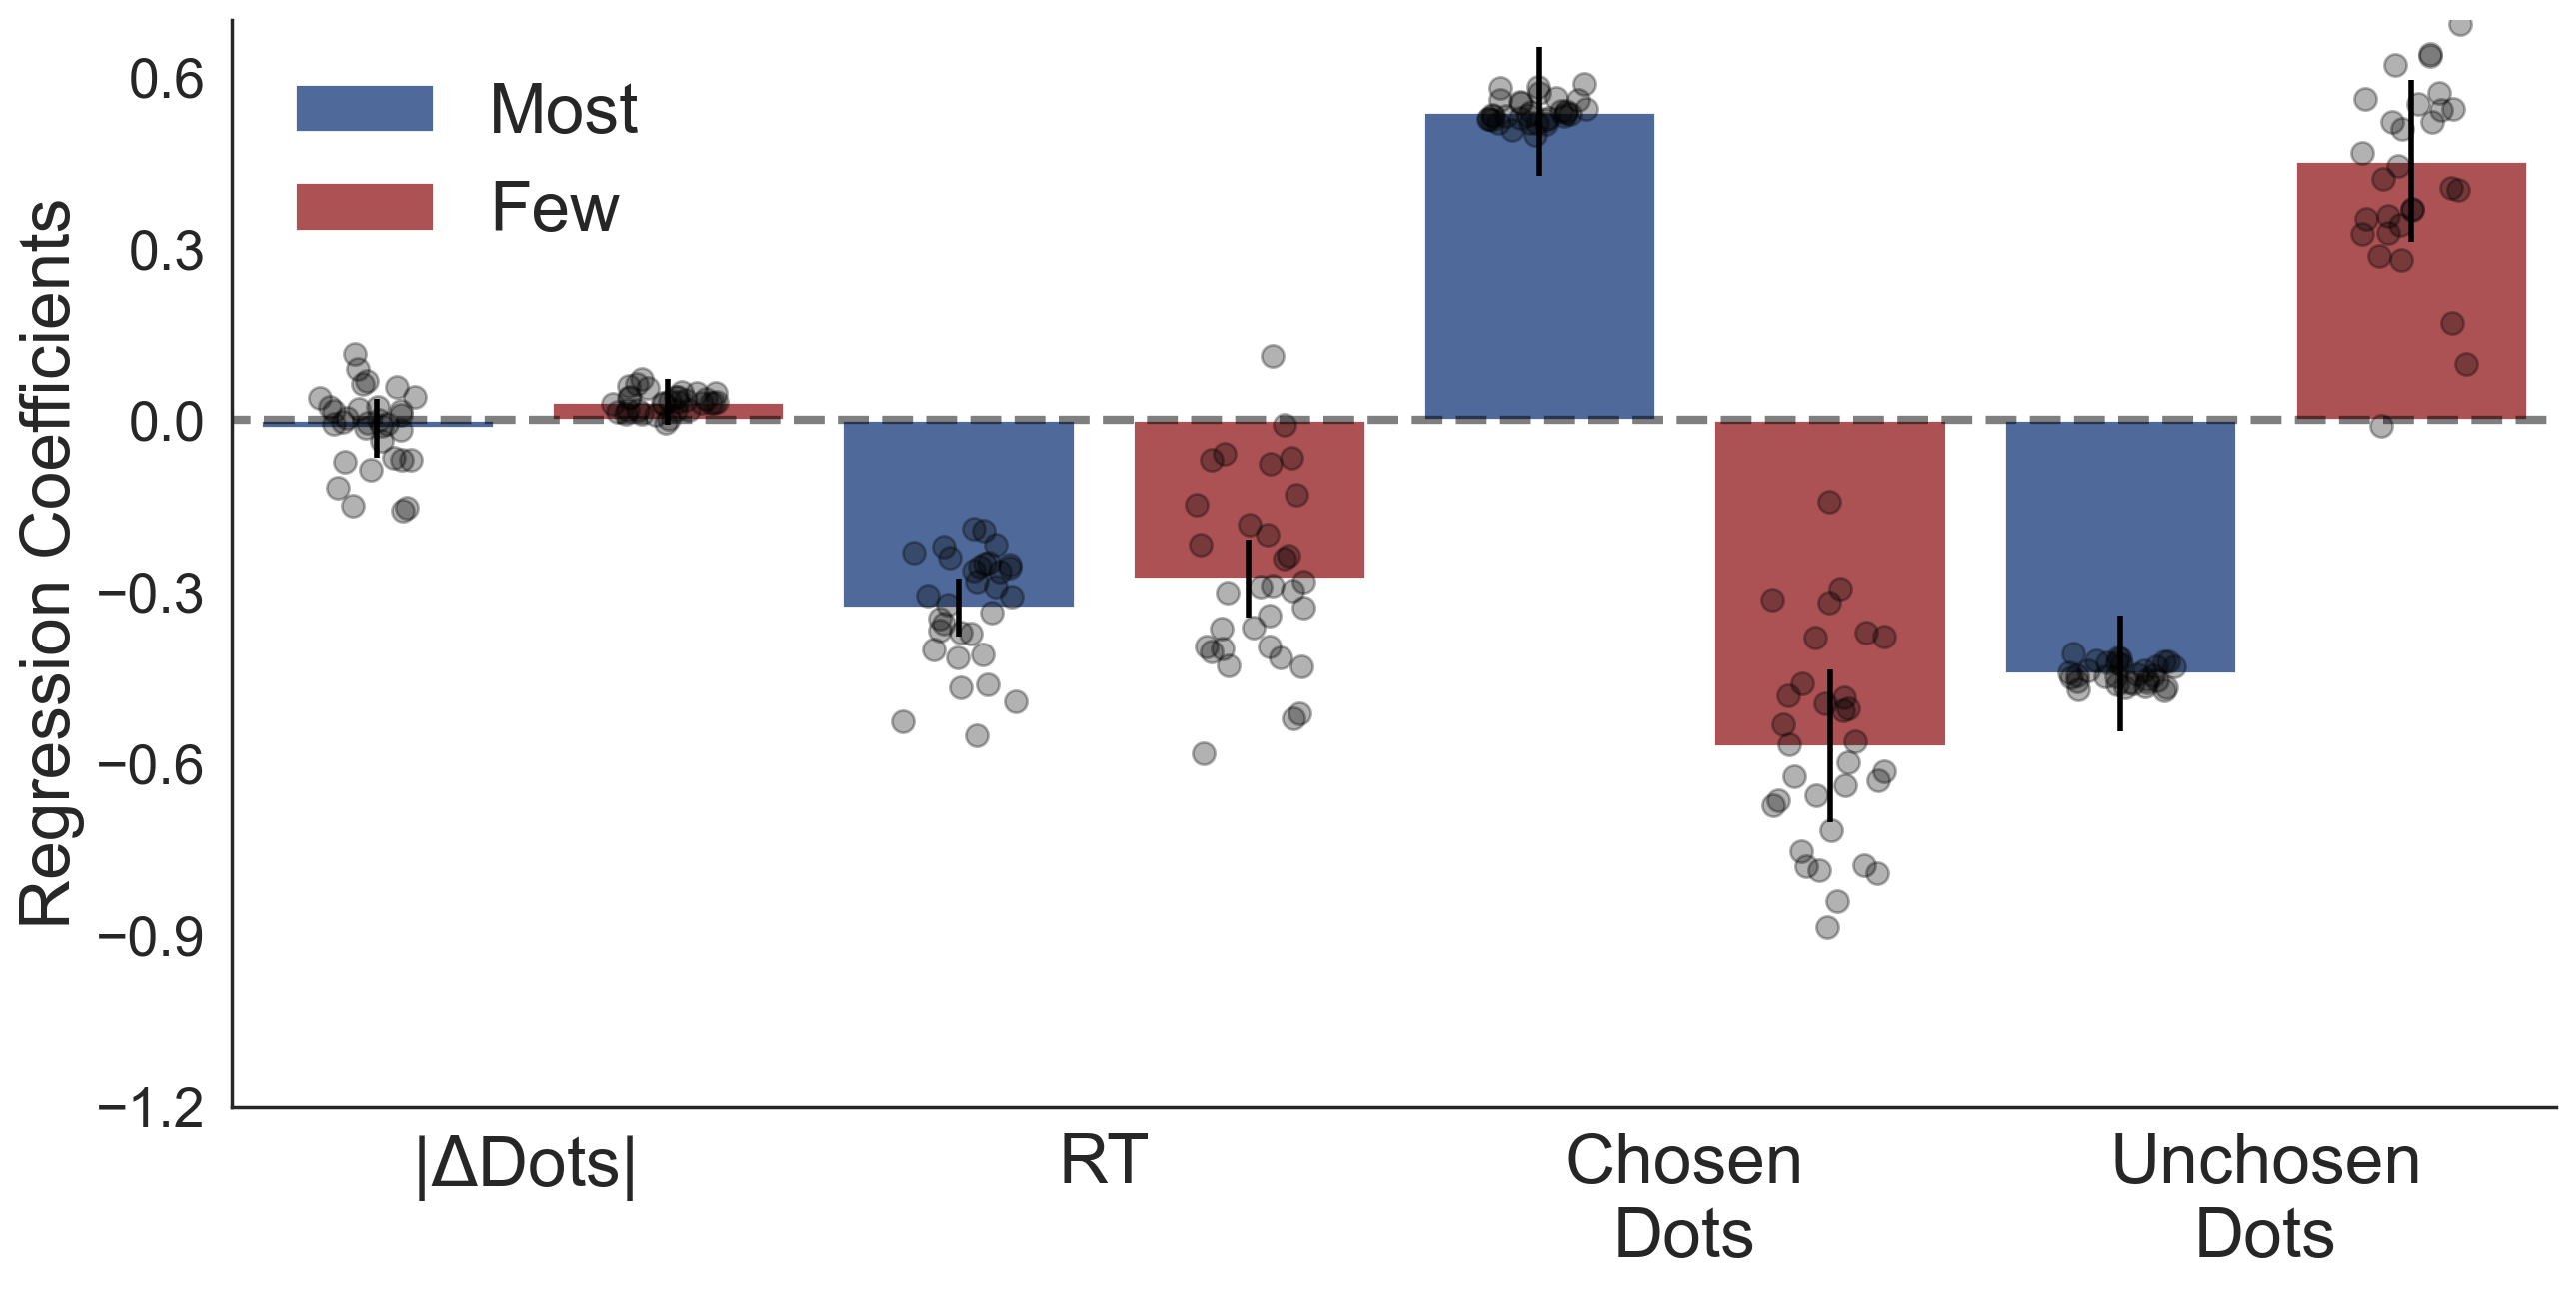

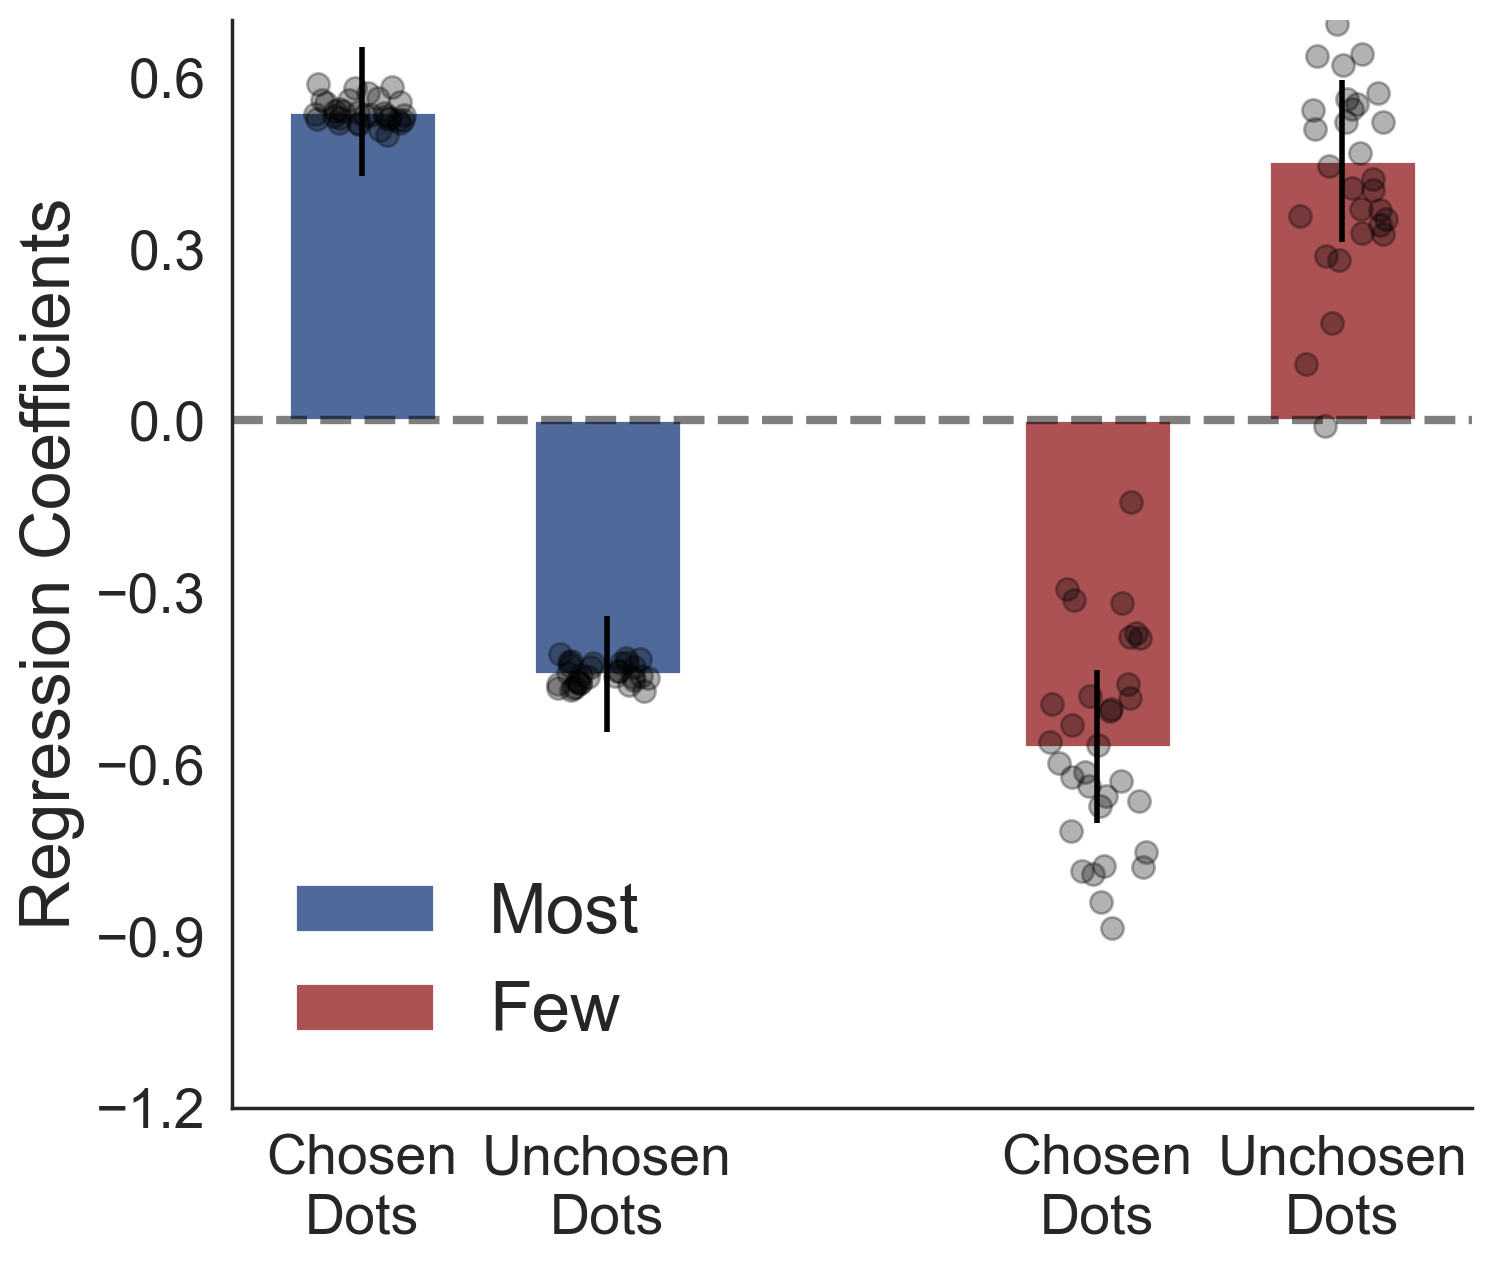

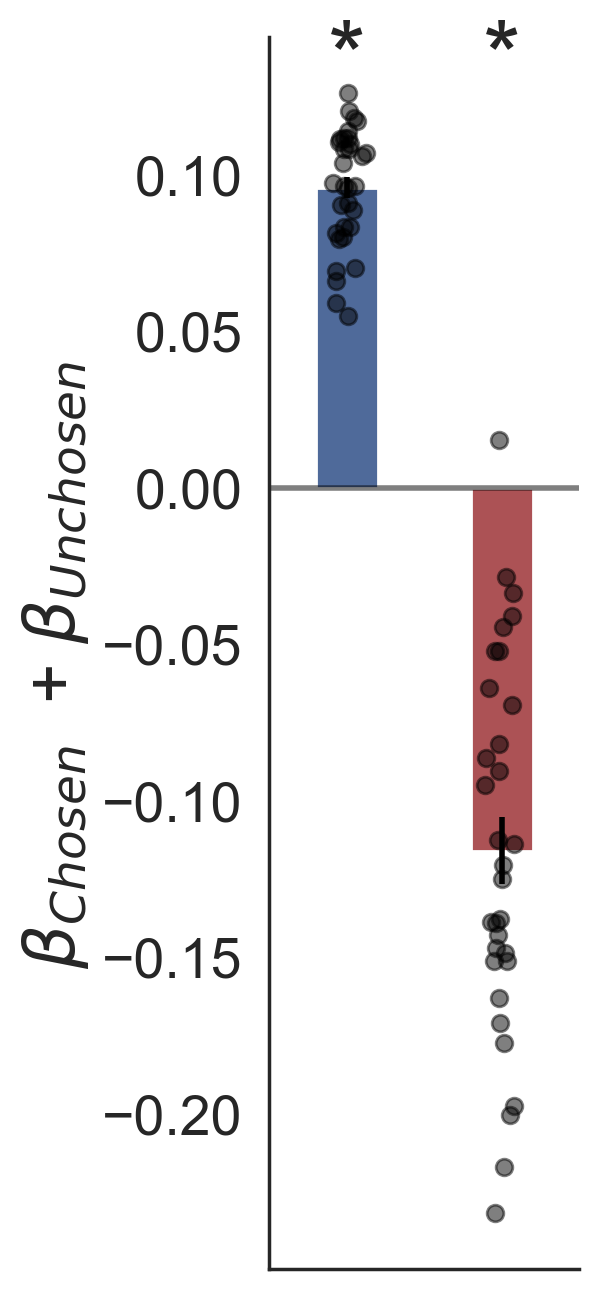

t-test positive vs negative frame = 0.1 +- 0.0033295606271854655 vs -0.12 +-0.010614029292348785
; t =  18.358 ; p-value =3.2771507060886366e-18


In [14]:
# Figure 1D: frames Most (MORE) / Fewest (LESS)
data_all = pd.read_csv('../Data/Sepulveda2020/DataPerceptualFramingNotebook.csv') 
# Positive (high-evidence goal) frame

print('================  Pos frame =====================')

data_part_all0 =  data_all.loc[data_all.BlockCond == 'MORE']
data_part_all_Pos     = mainLoad(data_part_all0)

# Negative (low-evidence goal) frame

print('================  Neg frame =====================')
data_part_all0 =  data_all.loc[data_all.BlockCond == 'LESS']
data_part_all_Neg     = mainLoad(data_part_all0)

regressionHuman_ChoUncho(data_part_all_Pos,data_part_all_Neg, labels = ['Inter','|$\Delta$Dots|','RT','Chosen\nDots', 'Unchosen\nDots'], labelFrame = ['Most','Few'],
                         formula =  "zConf ~ zabsDValue+ zRT +  zChoValue + zUnchoValue + (zabsDValue + zRT +  zChoValue + zUnchoValue|Part) ")

## Experiment 4 – auditory clicks

================  Pos frame =====================
================  Neg frame =====================
R messages: 
Convergence status
: [1] FALSE
attr(,"gradient")
[1] 0.002252691

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

Regression results for Positive Frame:
term       (Intercept)  zabsDValue           zRT     zChoValue   zUnchoValue
Estimate -6.367392e-17    0.080852 -2.994274e-01  1.594427e-01 -2.358565e-01
SE        1.544845e-02    0.027550  2.916923e-02  2.272823e-02  3.744527e-02
2.5_ci   -3.029156e-02    0.024738 -3.588679e-01  1.142032e-01 -3.126427e-01
97.5_ci   3.029156e-02    0.136966 -2.399869e-01  2.046822e-01 -1.590702e-01
t_stat   -4.121704e-15    2.934690 -1.026518e+01  7.015186e+00 -6.298699e+00
DF        2.785105

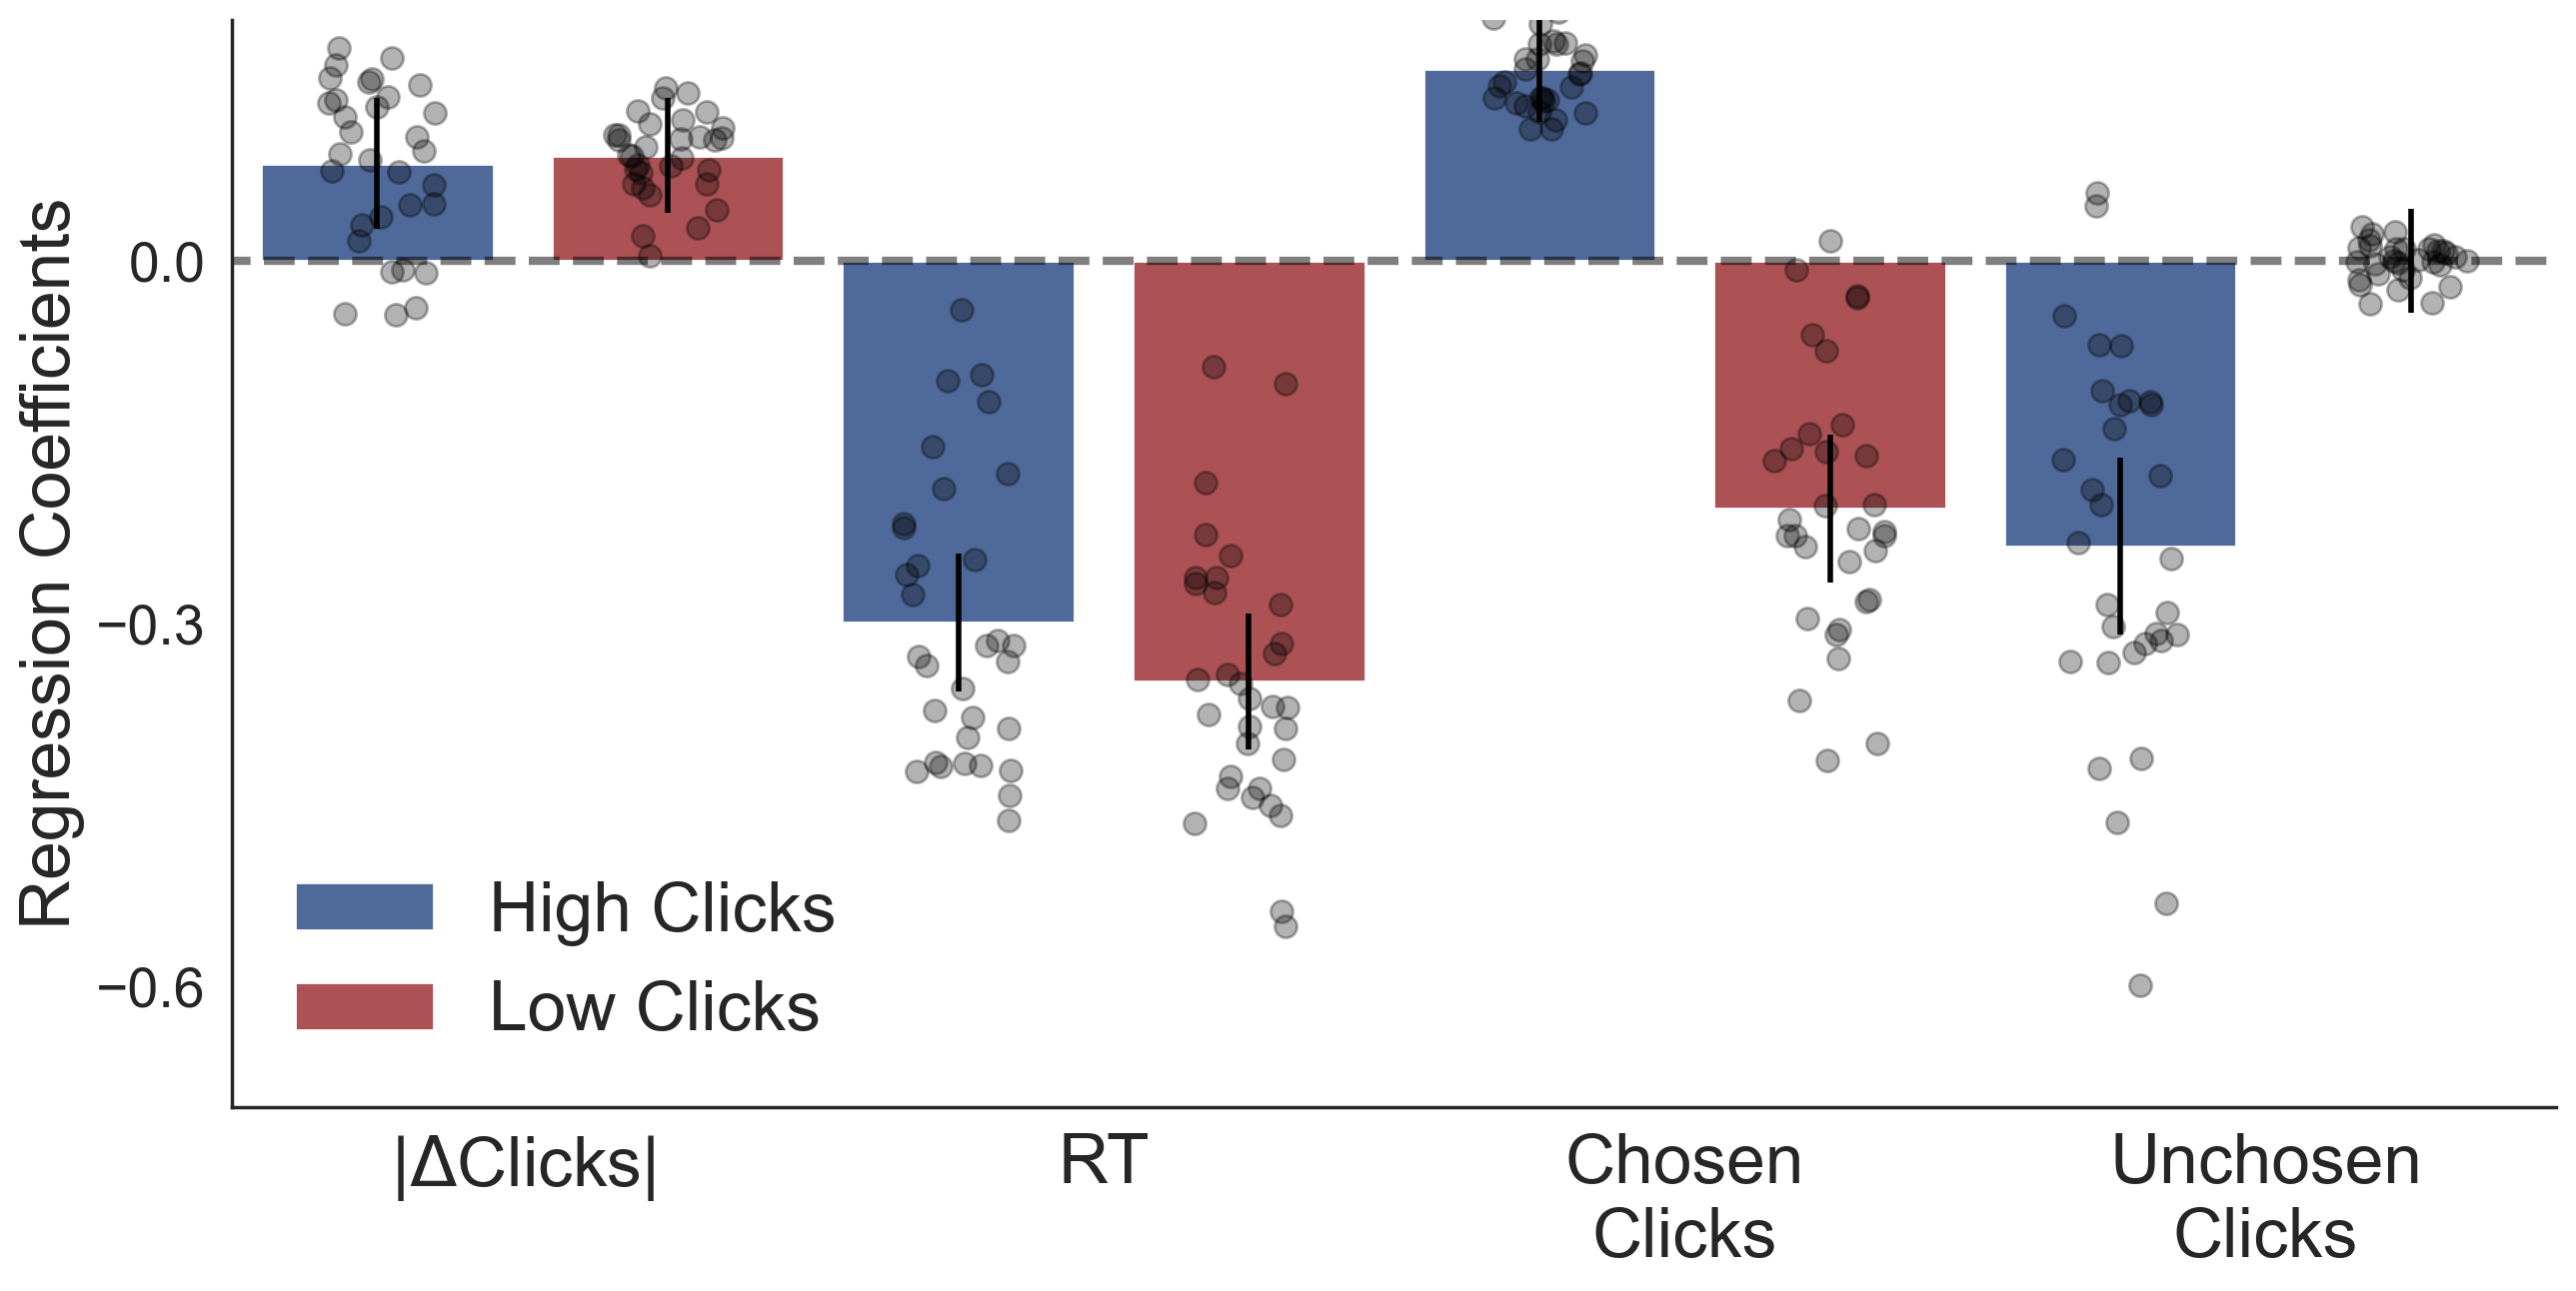

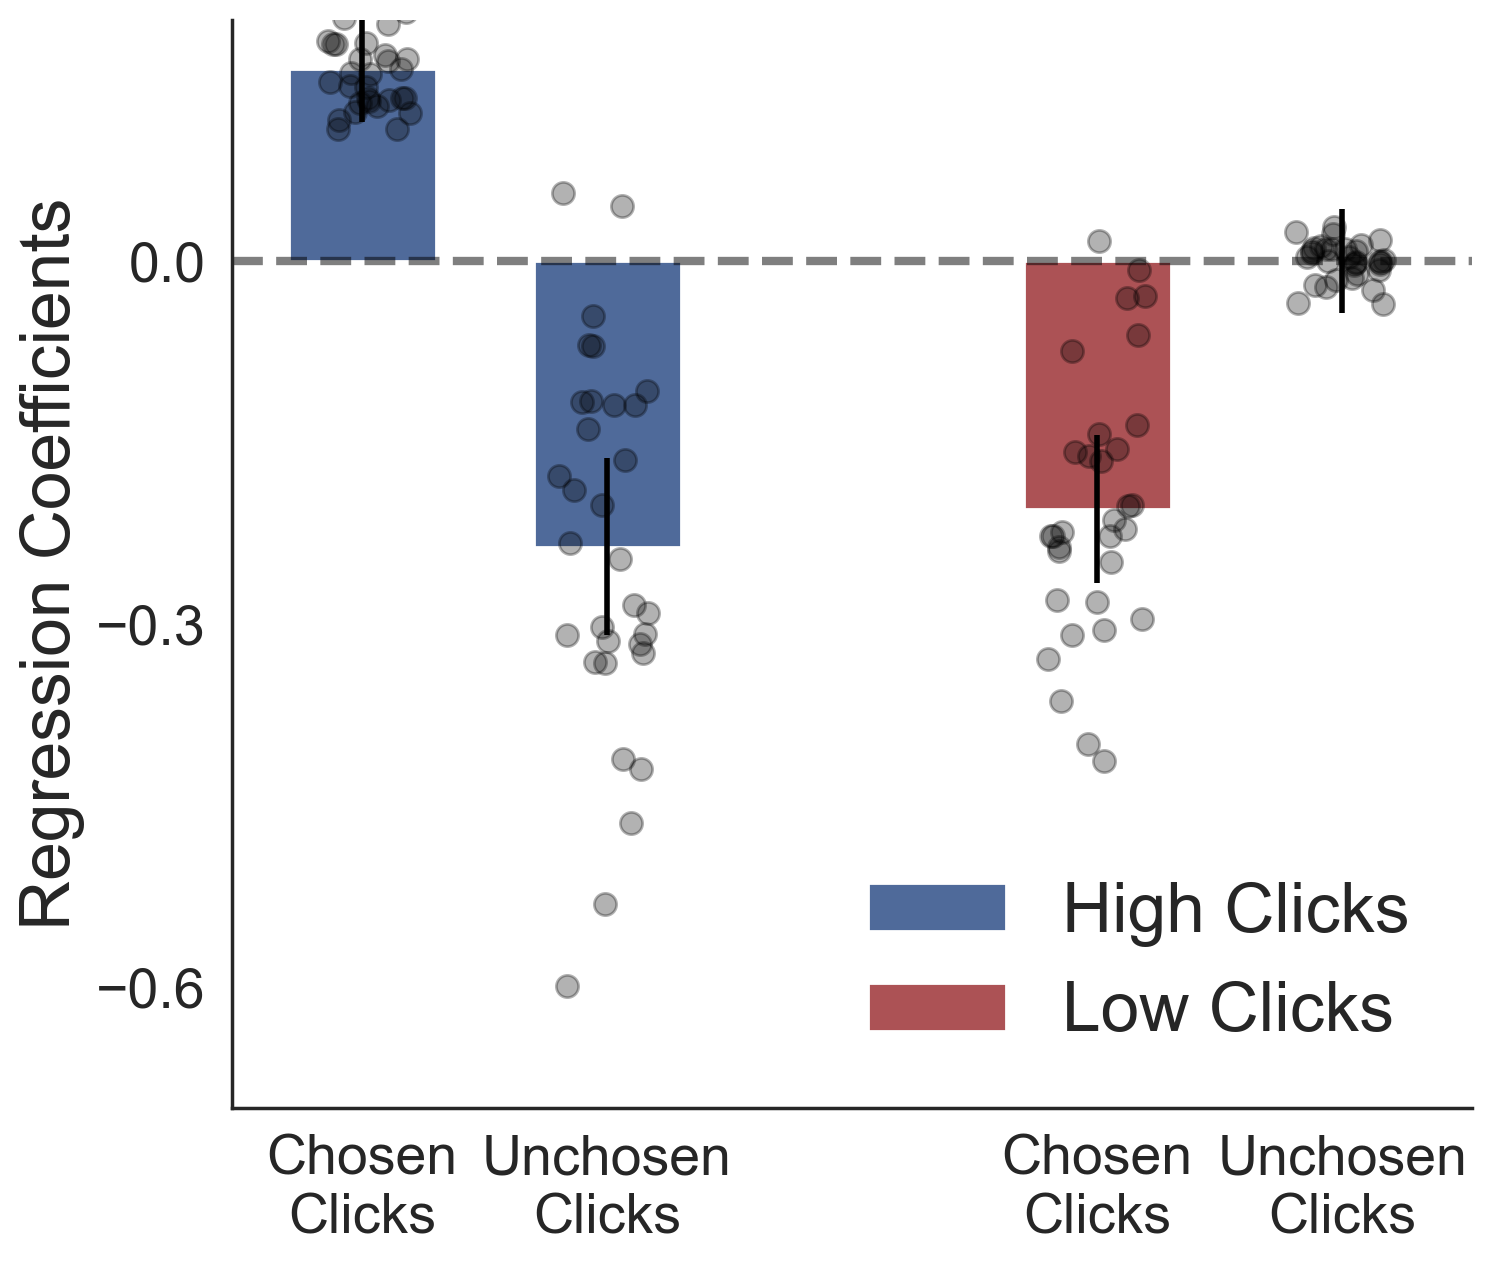

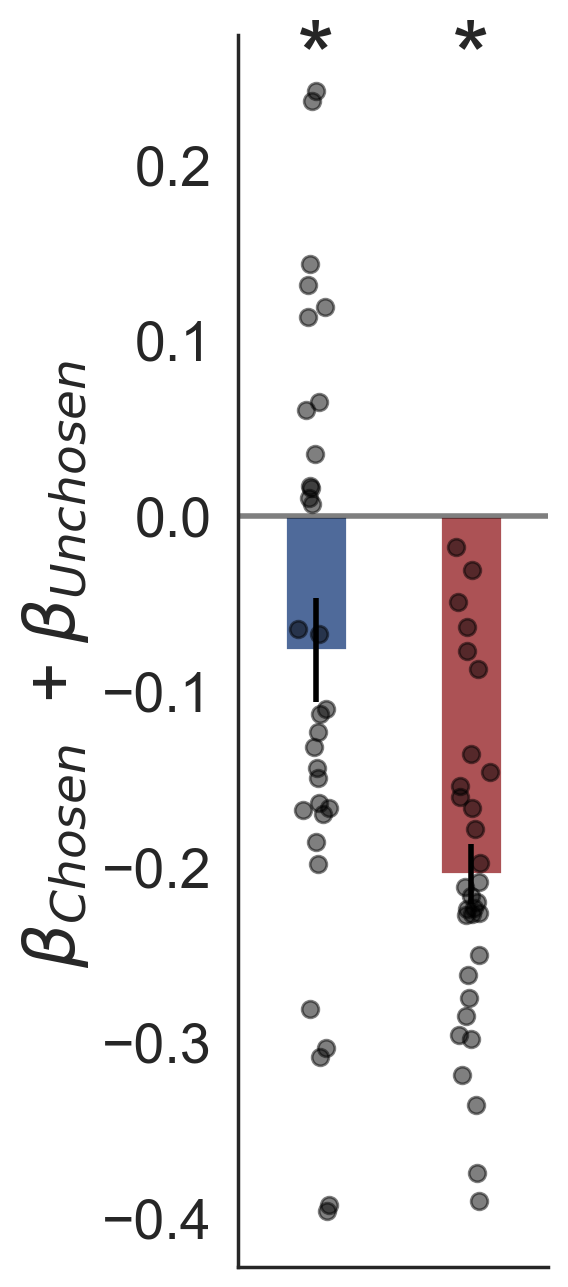

t-test positive vs negative frame = -0.08 +- 0.029696106628933308 vs -0.2 +-0.016933227904266678
; t =  5.851 ; p-value =1.8738107819303662e-06


In [15]:
# Figure 1H: frames High Clicks (frame == 1) / Low Clicks (frame == 2)
data_all = pd.read_csv('../Data/SepulvedaNew/Pupil2022_FullData_Dec2022.csv')

data_all = data_all.rename(columns = {'Choice':'ChosenITM','Choice_SND1_RT':'ChoiceRT' ,'CONF': 'Conf', 'freql':'LValue','freqr':'RValue','part':'Part' })
                           
# Positive (high-evidence goal) frame
print('================  Pos frame =====================')

data_part_all0 =  data_all.loc[data_all.frame == 1]
data_part_all_Pos     = mainLoad(data_part_all0)

# Negative (low-evidence goal) frame

print('================  Neg frame =====================')
data_part_all0 =  data_all.loc[data_all.frame == 2]
data_part_all_Neg     = mainLoad(data_part_all0)

regressionHuman_ChoUncho(data_part_all_Pos,data_part_all_Neg, labels = ['Inter','|$\Delta$Clicks|','RT','Chosen\nClicks', 'Unchosen\nClicks'], labelFrame = ['High Clicks','Low Clicks'],
                         formula =  "zConf ~ zabsDValue+ zRT +  zChoValue + zUnchoValue + (zabsDValue + zRT +  zChoValue + zUnchoValue|Part) ")

## Experiment 3 – dot motion

================  Pos frame =====================
================  Neg frame =====================
R messages: 
Convergence status
: [1] FALSE
attr(,"gradient")
[1] 0.001579336

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] 0.009162219

Regression results for Positive Frame:
term       (Intercept)  zabsDValue           zRT     zChoValue   zUnchoValue
Estimate -1.892559e-16   -0.030891 -3.136969e-01  2.862317e-01 -2.435014e-01
SE        1.061270e-02    0.029562  2.478402e-02  3.142758e-02  2.541563e-02
2.5_ci   -2.080447e-02   -0.093256 -3.644660e-01  2.196087e-01 -2.960122e-01
97.5_ci   2.080447e-02    0.031473 -2.629279e-01  3.528547e-01 -1.909906e-01
t_stat   -1.783295e-14   -1.0

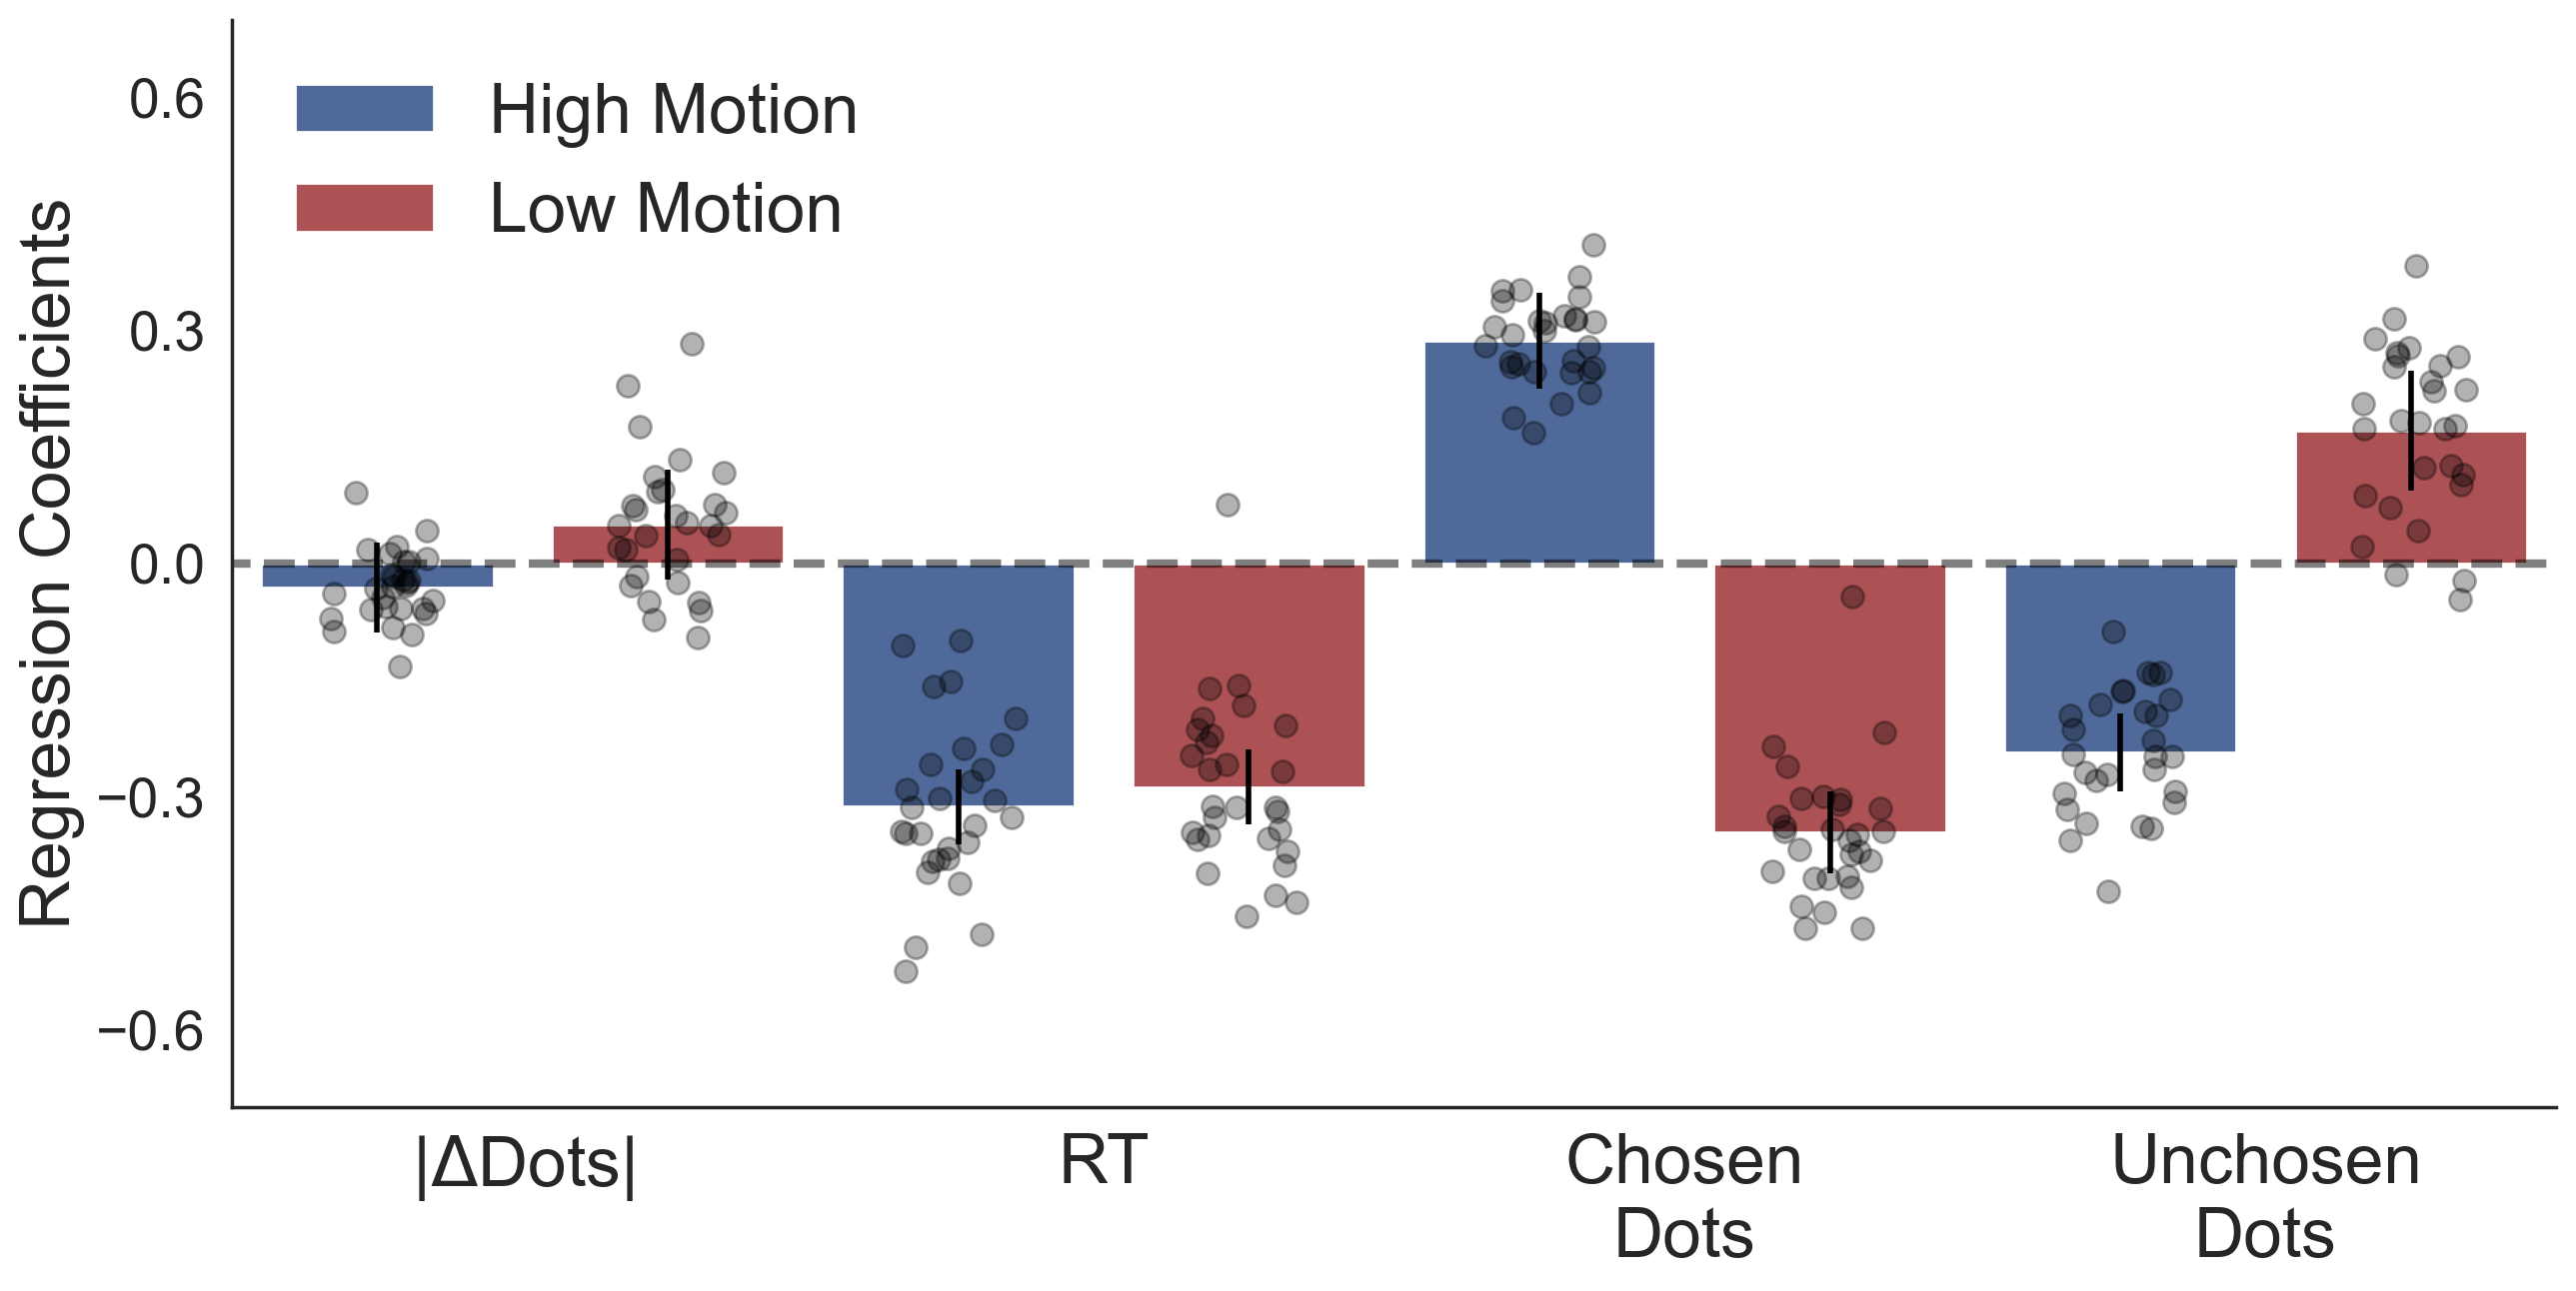

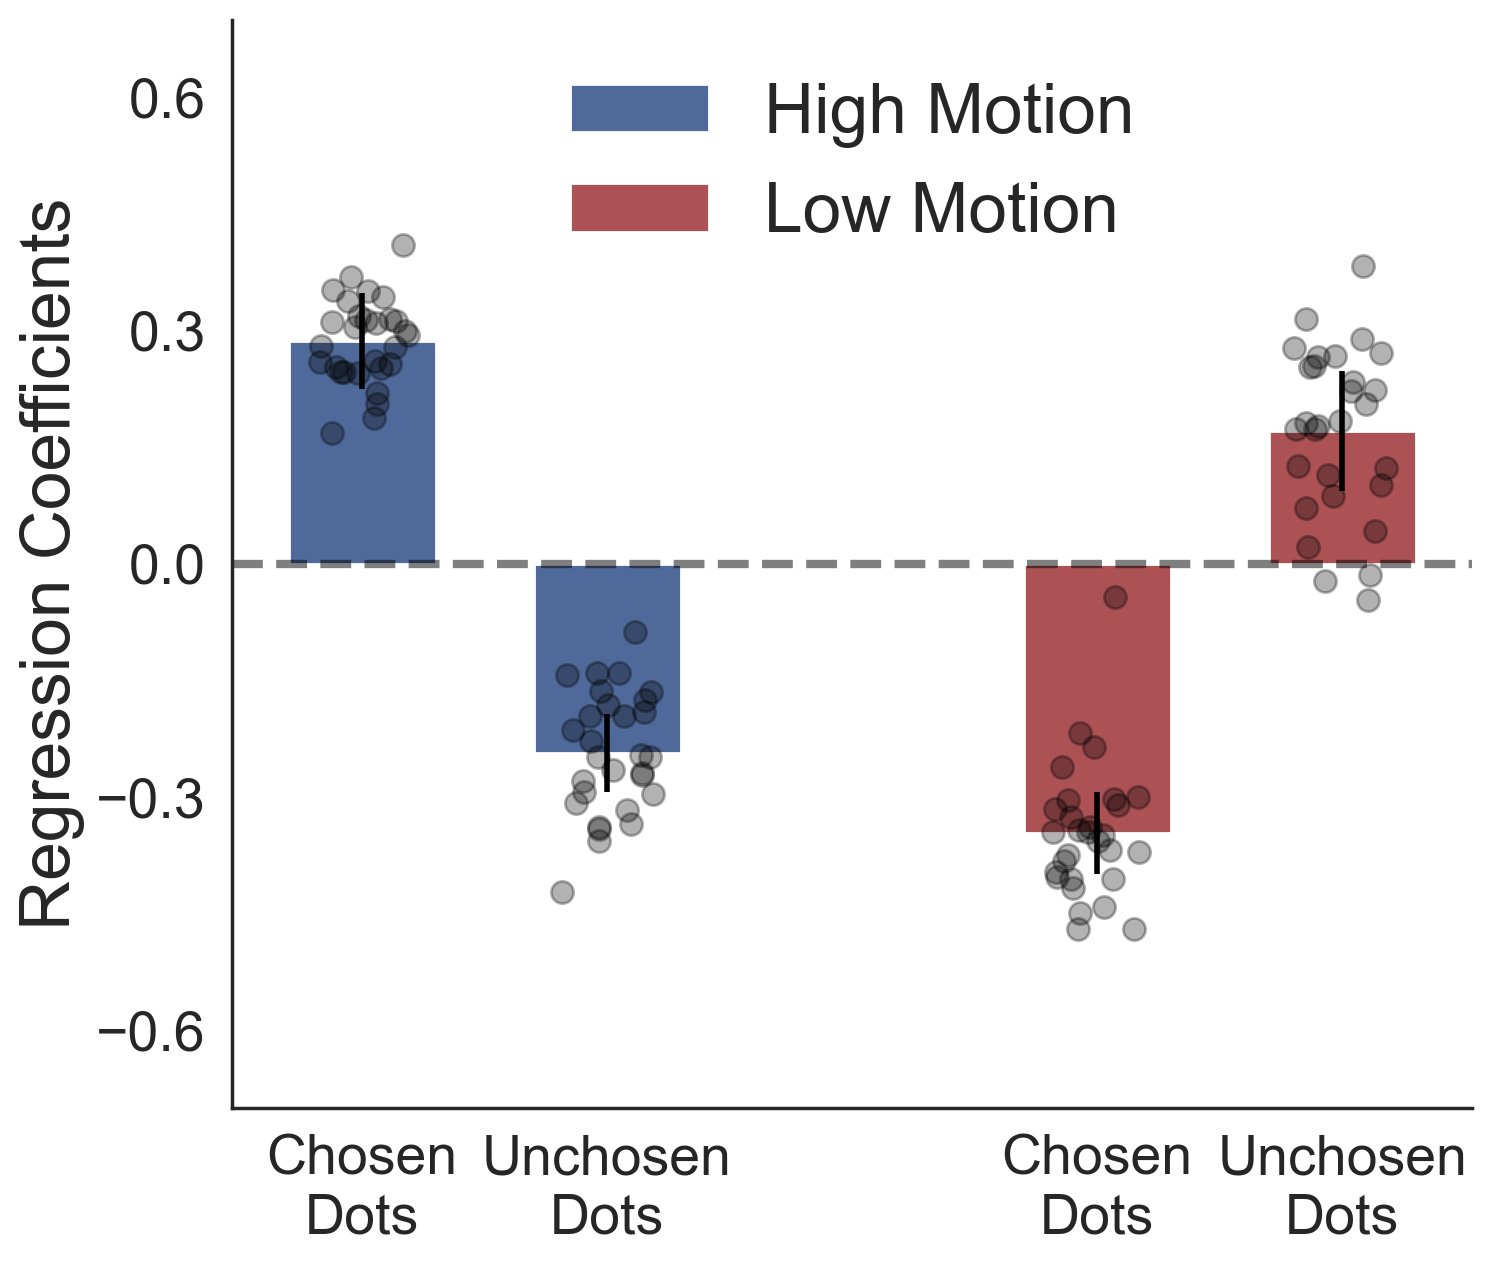

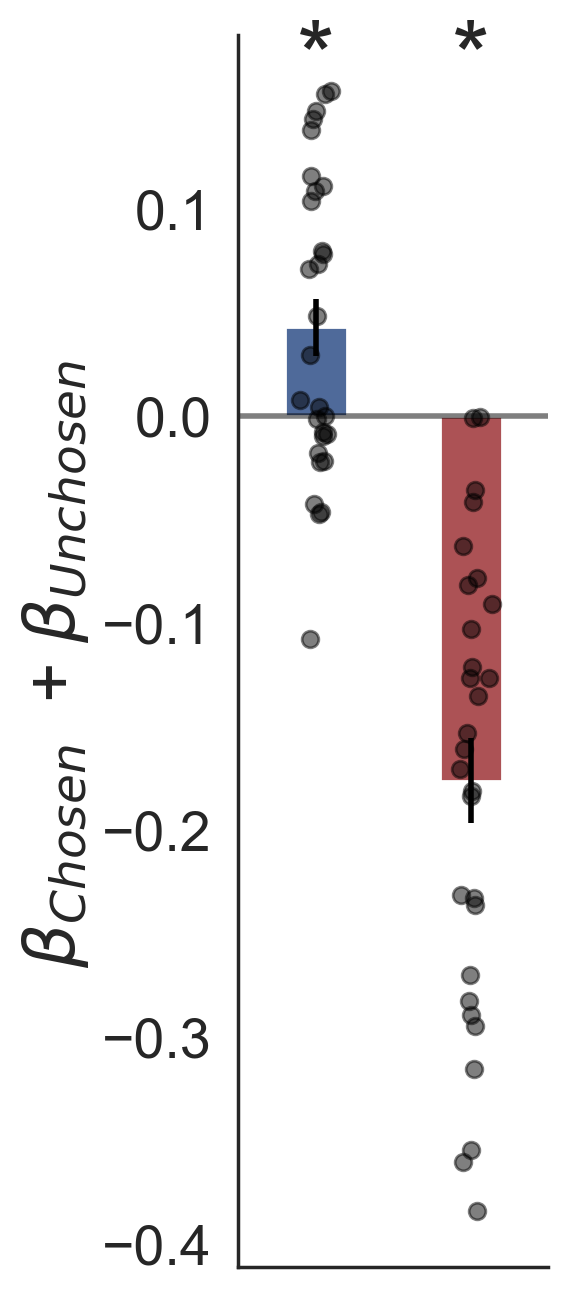

t-test positive vs negative frame = 0.04 +- 0.013647698603837575 vs -0.18 +-0.020437847896035862
; t =  9.625 ; p-value =2.2246870380758712e-10


In [16]:
# Figure 1F: frames High Motion (Frame == 1) / Low Motion (Frame == 2)
data_all = pd.read_csv('../Data/SepulvedaNew/RDMFrame_FullProlificData_CoherenceControl_Apr2021.csv')

data_all = data_all.rename(columns = {'Choice':'ChosenITM','Reaction Time':'ChoiceRT' ,'CONF': 'Conf', 'LDot':'LValue','RDot':'RValue' })
                           
# Positive (high-evidence goal) frame
print('================  Pos frame =====================')

data_part_all0 =  data_all.loc[data_all.Frame == 1]
data_part_all_Pos     = mainLoad(data_part_all0, )

# Negative (low-evidence goal) frame

print('================  Neg frame =====================')
data_part_all0 =  data_all.loc[data_all.Frame == 2]
data_part_all_Neg     = mainLoad(data_part_all0)

regressionHuman_ChoUncho(data_part_all_Pos,data_part_all_Neg, labels = ['Inter','|$\Delta$Dots|','RT','Chosen\nDots', 'Unchosen\nDots'], labelFrame = ['High Motion','Low Motion'],
                         formula =  "zConf ~ zabsDValue+ zRT +  zChoValue + zUnchoValue + (zabsDValue + zRT +  zChoValue + zUnchoValue|Part) ")